In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
from tqdm import tqdm
import os
import gc


In [2]:
# 读取数据
clustering_results = pd.read_csv("/media/ubuntu/sda/visual_stimuli_pattern/dynamic/clustering_results.csv")
tsne_features = pd.read_csv("/media/ubuntu/sda/visual_stimuli_pattern/dynamic/tsne_features.csv")

print(f"数据形状: {clustering_results.shape}")
print(f"t-SNE特征形状: {tsne_features.shape}")
print(f"K-means cluster数量: {clustering_results['kmeans_cluster'].nunique()}")
print(f"唯一cluster: {sorted(clustering_results['kmeans_cluster'].unique())}")


数据形状: (22248, 6)
t-SNE特征形状: (22248, 4)
K-means cluster数量: 20
唯一cluster: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [3]:
def generate_all_clusters_scatter_pdf():
    """
    生成包含所有cluster的散点图PDF，并在每个cluster位置标注cluster名称
    """
    # 设置matplotlib参数
    plt.rcParams['figure.figsize'] = (16, 12)
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['axes.labelsize'] = 14
    
    # 创建PDF文件
    output_path = "/media/ubuntu/sda/visual_stimuli_pattern/dynamic/all_clusters_scatter_plot.pdf"
    
    # 获取所有唯一的cluster
    unique_clusters = sorted(clustering_results['kmeans_cluster'].unique())
    print(f"找到 {len(unique_clusters)} 个不同的cluster")
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # 为每个cluster分配不同的颜色
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))
    
    # 计算每个cluster的中心位置用于标注
    cluster_centers = {}
    
    # 绘制每个cluster
    for i, cluster_id in enumerate(unique_clusters):
        cluster_mask = clustering_results['kmeans_cluster'] == cluster_id
        
        if cluster_mask.sum() > 0:
            # 绘制cluster点
            ax.scatter(tsne_features.loc[cluster_mask, 'tSNE1'],
                      tsne_features.loc[cluster_mask, 'tSNE2'],
                      c=[colors[i]], alpha=0.7, s=2, 
                      label=f'Cluster {cluster_id} ({cluster_mask.sum():,} points)')
            
            # 计算cluster中心位置
            center_x = tsne_features.loc[cluster_mask, 'tSNE1'].mean()
            center_y = tsne_features.loc[cluster_mask, 'tSNE2'].mean()
            cluster_centers[cluster_id] = (center_x, center_y)
    
    # 在cluster中心位置添加标注
    for cluster_id, (center_x, center_y) in cluster_centers.items():
        ax.annotate(f'C{cluster_id}', 
                   (center_x, center_y),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                   ha='left')
    
    # 设置图形属性
    ax.set_xlabel('t-SNE Dimension 1', fontsize=14)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=14)
    ax.set_title('All K-means Clusters Visualization', fontsize=18, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 添加图例（放在图形外部）
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # 添加统计信息
    total_points = len(clustering_results)
    info_text = f'Total points: {total_points:,}\nTotal clusters: {len(unique_clusters)}'
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=12,
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    
    # 保存为PDF
    with PdfPages(output_path) as pdf:
        pdf.savefig(fig, bbox_inches='tight', dpi=300)
    
    plt.close(fig)
    
    print(f"\nPDF文件已生成: {output_path}")
    
    # 显示文件大小
    file_size = os.path.getsize(output_path) / (1024 * 1024)  # MB
    print(f"文件大小: {file_size:.2f} MB")
    
    return output_path

# 运行函数
generate_all_clusters_scatter_pdf()


找到 20 个不同的cluster

PDF文件已生成: /media/ubuntu/sda/visual_stimuli_pattern/dynamic/all_clusters_scatter_plot.pdf
文件大小: 0.37 MB


'/media/ubuntu/sda/visual_stimuli_pattern/dynamic/all_clusters_scatter_plot.pdf'

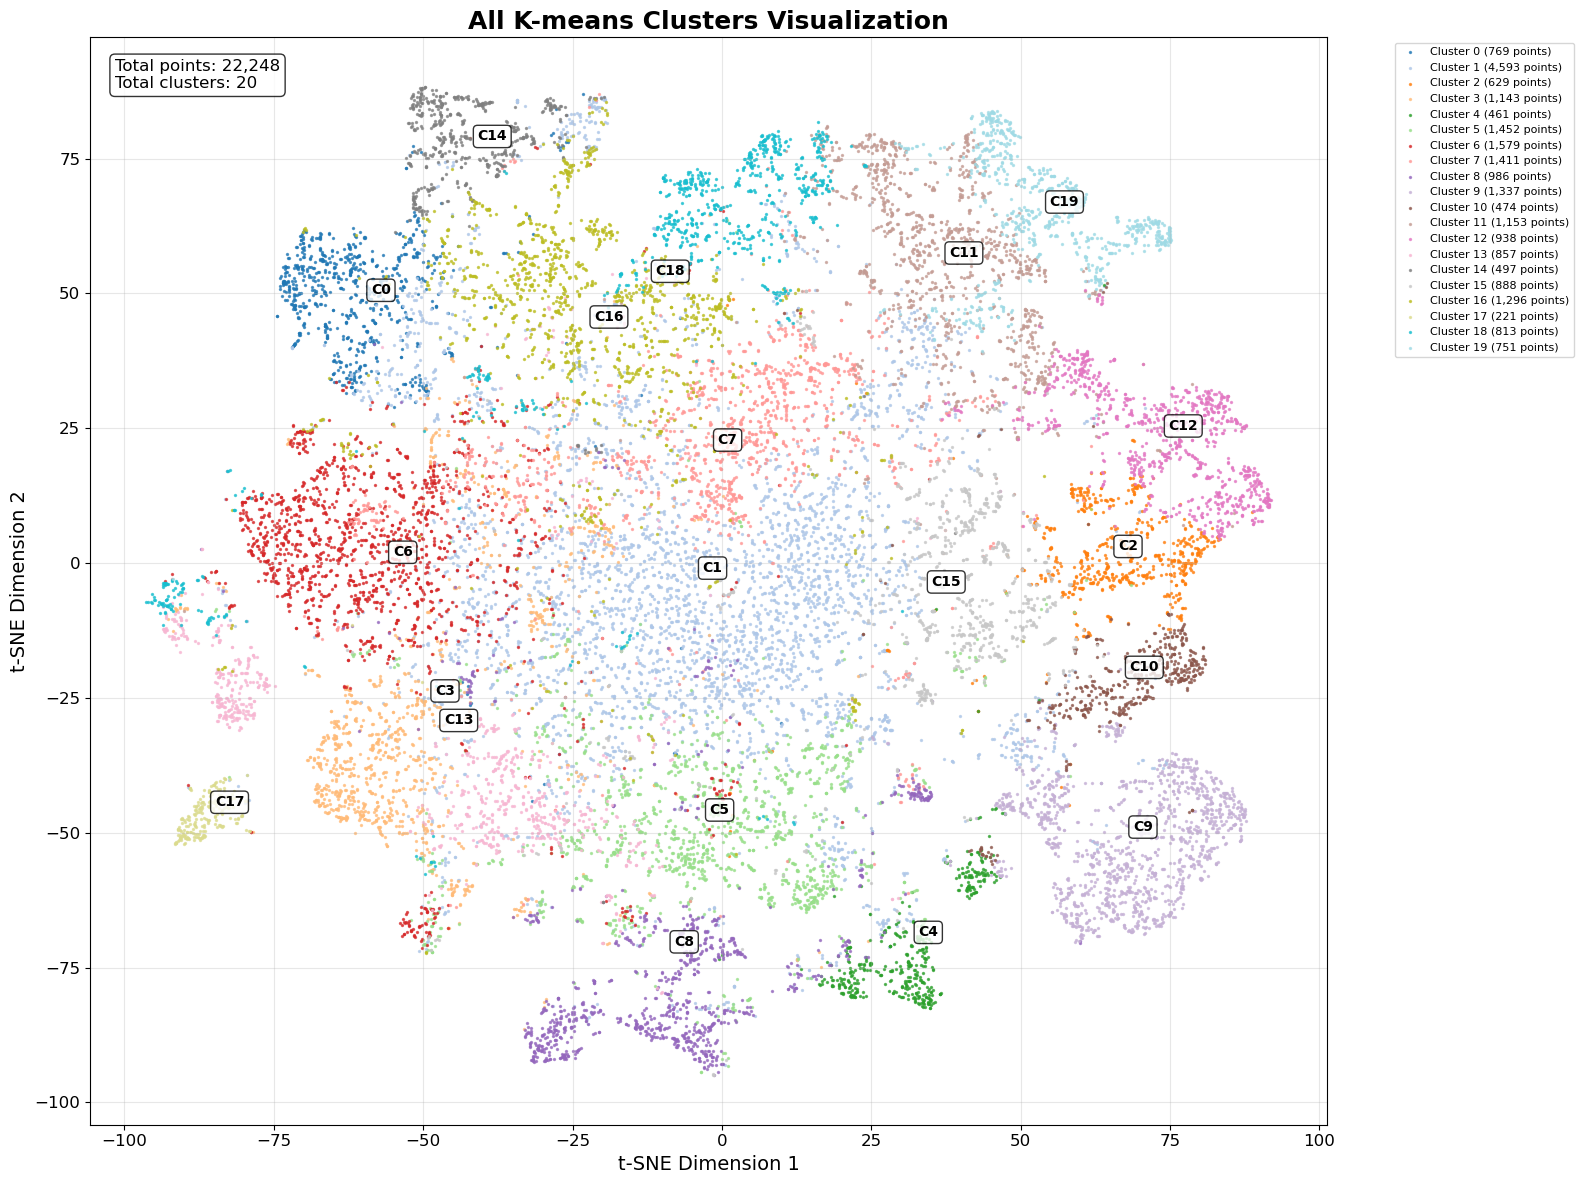

In [4]:
def visualize_all_clusters_in_notebook():
    """
    在notebook中直接显示所有cluster的散点图
    """
    # 设置图形大小
    plt.figure(figsize=(16, 12))
    
    # 获取所有唯一的cluster
    unique_clusters = sorted(clustering_results['kmeans_cluster'].unique())
    
    # 为每个cluster分配不同的颜色
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))
    
    # 计算每个cluster的中心位置用于标注
    cluster_centers = {}
    
    # 绘制每个cluster
    for i, cluster_id in enumerate(unique_clusters):
        cluster_mask = clustering_results['kmeans_cluster'] == cluster_id
        
        if cluster_mask.sum() > 0:
            # 绘制cluster点
            plt.scatter(tsne_features.loc[cluster_mask, 'tSNE1'],
                       tsne_features.loc[cluster_mask, 'tSNE2'],
                       c=[colors[i]], alpha=0.7, s=2, 
                       label=f'Cluster {cluster_id} ({cluster_mask.sum():,} points)')
            
            # 计算cluster中心位置
            center_x = tsne_features.loc[cluster_mask, 'tSNE1'].mean()
            center_y = tsne_features.loc[cluster_mask, 'tSNE2'].mean()
            cluster_centers[cluster_id] = (center_x, center_y)
    
    # 在cluster中心位置添加标注
    for cluster_id, (center_x, center_y) in cluster_centers.items():
        plt.annotate(f'C{cluster_id}', 
                    (center_x, center_y),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                    ha='left')
    
    # 设置图形属性
    plt.xlabel('t-SNE Dimension 1', fontsize=14)
    plt.ylabel('t-SNE Dimension 2', fontsize=14)
    plt.title('All K-means Clusters Visualization', fontsize=18, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # 添加图例
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # 添加统计信息
    total_points = len(clustering_results)
    info_text = f'Total points: {total_points:,}\nTotal clusters: {len(unique_clusters)}'
    plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# 在notebook中显示图形
visualize_all_clusters_in_notebook()


In [5]:
# 显示cluster统计信息
print("Cluster统计信息:")
cluster_stats = clustering_results['kmeans_cluster'].value_counts().sort_index()
print(cluster_stats)

print("\nCluster大小分布:")
print(f"最大cluster大小: {cluster_stats.max():,} 个点")
print(f"最小cluster大小: {cluster_stats.min():,} 个点")
print(f"平均cluster大小: {cluster_stats.mean():.1f} 个点")


Cluster统计信息:
kmeans_cluster
0      769
1     4593
2      629
3     1143
4      461
5     1452
6     1579
7     1411
8      986
9     1337
10     474
11    1153
12     938
13     857
14     497
15     888
16    1296
17     221
18     813
19     751
Name: count, dtype: int64

Cluster大小分布:
最大cluster大小: 4,593 个点
最小cluster大小: 221 个点
平均cluster大小: 1112.4 个点
